# Experiment 3: Dimensionality Reduction Using Principal Component Analysis (PCA)

## Mapped CO(s): CO2, CO4

### **Aim:**
To perform dimensionality reduction using Principal Component Analysis (PCA) on the Titanic dataset using Python.

### **Objectives:**
1. To understand the concept of dimensionality reduction.
2. To preprocess data before applying PCA.
3. To standardize numerical features.
4. To apply PCA using Scikit-learn.
5. To visualize the principal components.
6. To analyze the explained variance of each principal component.

### **Theory/Background**
**Principal Component Analysis (PCA)** is an unsupervised machine learning technique used for dimensionality reduction. It transforms a large set of correlated variables into a smaller set of new, uncorrelated variables called **Principal Components**, while preserving as much information (variance) as possible.

- **First Principal Component (PC1)**: Captures the maximum variance in the dataset.
- **Second Principal Component (PC2)**: Captures the remaining variance while being orthogonal (perpendicular) to the first component.

Numerical features must be standardized before applying PCA (mean = 0, variance = 1) because PCA is sensitive to the variance of the initial variables. Features with larger ranges would dominate the components otherwise.

## **Step 1: Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

## **Step 2: Load the Titanic Dataset**

In [ ]:
# Load Titanic dataset from seaborn
df = sns.load_dataset('titanic')
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## **Step 3: Select Numerical Features & Handle Missing Values**
We select the numerical attributes: `age`, `fare`, `sibsp`, `parch`, and `pclass` as specified in the experiment guidelines. We then drop any rows containing missing values in these columns.

In [ ]:
# Define features to be used
numerical_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']

# Check for missing values in selected features
print("Missing values per column before cleanup:")
print(df[numerical_cols].isnull().sum())

# Create subset and drop rows with missing values
# Keep track of 'survived' status for visualization hue
df_clean = df[numerical_cols + ['survived']].dropna()

X = df_clean[numerical_cols]
y = df_clean['survived']

print(f"\nCleaned dataset shape: {X.shape}")
X.head()

Missing values per column before cleanup:
age       177
fare        0
sibsp       0
parch       0
pclass      0
dtype: int64

Cleaned dataset shape: (714, 5)


,age,fare,sibsp,parch,pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


## **Step 4: Standardize the Numerical Data**
We standardize the features using `StandardScaler` so that each feature has a mean of 0 and standard deviation of 1.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for visualization of preprocessed features
df_scaled = pd.DataFrame(X_scaled, columns=numerical_cols)
print("Mean of standardized features (should be ~0):")
print(df_scaled.mean().round(2))
print("\nStandard deviation of standardized features (should be 1):")
print(df_scaled.std().round(2))

Mean of standardized features (should be ~0):
age       0.0
fare     -0.0
sibsp    -0.0
parch    -0.0
pclass   -0.0
dtype: float64

Standard deviation of standardized features (should be 1):
age       1.0
fare      1.0
sibsp     1.0
parch     1.0
pclass    1.0
dtype: float64


## **Step 5: Apply PCA to Reduce Dimensions to 2D**
We initialize `PCA` with 2 components and apply it to our standardized data.

In [5]:
# Initialize PCA with 2 components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create a DataFrame with the principal components
df_pca_2d = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['Survived'] = y.values

print(f"Transformed dataset shape: {df_pca_2d.shape}")
df_pca_2d.head()

Transformed dataset shape: (714, 3)


,PC1,PC2,Survived
0,1.133045,-0.420339,0
1,-1.460888,0.654999,1
2,0.641975,-1.048999,1
3,-1.203606,0.514642,1
4,0.302516,-1.170015,0


## **Step 6: Display Explained Variance Ratio**
The explained variance ratio represents the proportion of the dataset's variance that lies along each principal component.

In [6]:
explained_variance = pca_2d.explained_variance_ratio_
print(f"Explained Variance for PC1: {explained_variance[0]:.4f} ({explained_variance[0]*100:.2f}%)")
print(f"Explained Variance for PC2: {explained_variance[1]:.4f} ({explained_variance[1]*100:.2f}%)")
print(f"Total Cumulative Explained Variance: {np.sum(explained_variance):.4f} ({np.sum(explained_variance)*100:.2f}%)")

Explained Variance for PC1: 0.3483 (34.83%)
Explained Variance for PC2: 0.3227 (32.27%)
Total Cumulative Explained Variance: 0.6710 (67.10%)


## **Step 7: Visualize Principal Components (2D Scatter Plot)**
We plot the first two principal components. Points are colored by whether the passenger survived (1) or did not survive (0) to see if the reduction reveals any pattern.

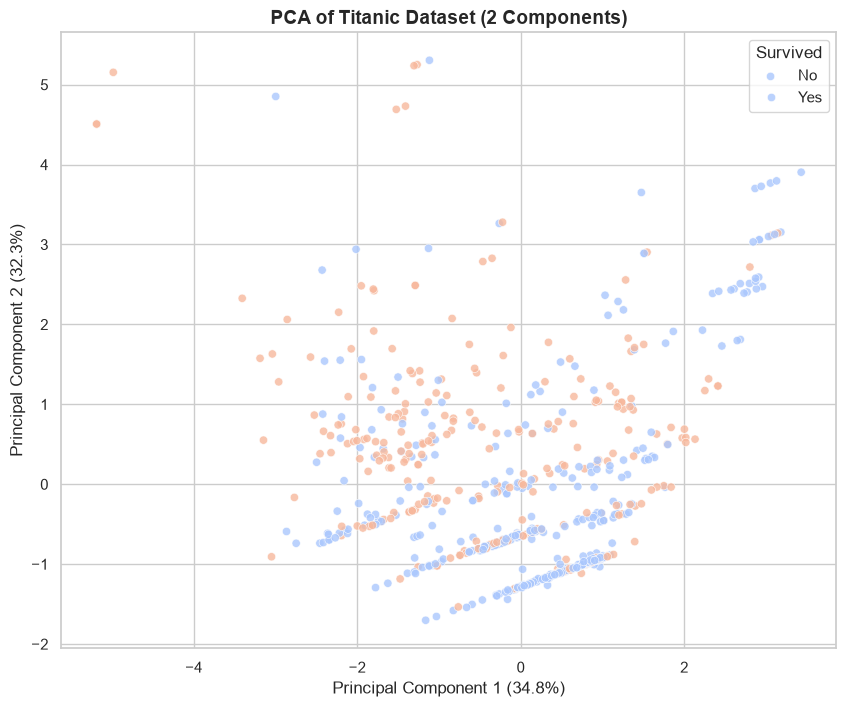

In [7]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Survived', data=df_pca_2d, palette='coolwarm', alpha=0.8)
plt.title('PCA of Titanic Dataset (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

---
# **Exercises/Assignments**

### **Exercise 1: Apply PCA using three principal components**
Apply PCA to the standardized features with `n_components=3`.

In [8]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create DataFrame
df_pca_3d = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['Survived'] = y.values

print(f"Transformed dataset shape with 3 components: {df_pca_3d.shape}")
df_pca_3d.head()

Transformed dataset shape with 3 components: (714, 4)


,PC1,PC2,PC3,Survived
0,1.133045,-0.420339,-0.376889,0
1,-1.460888,0.654999,-0.433426,1
2,0.641975,-1.048999,-0.164703,1
3,-1.203606,0.514642,-0.459494,1
4,0.302516,-1.170015,0.248261,0


### **Exercise 2: Plot the explained variance ratio of each component**
Plot a bar chart of the individual explained variance ratios and a line chart of the cumulative explained variance.

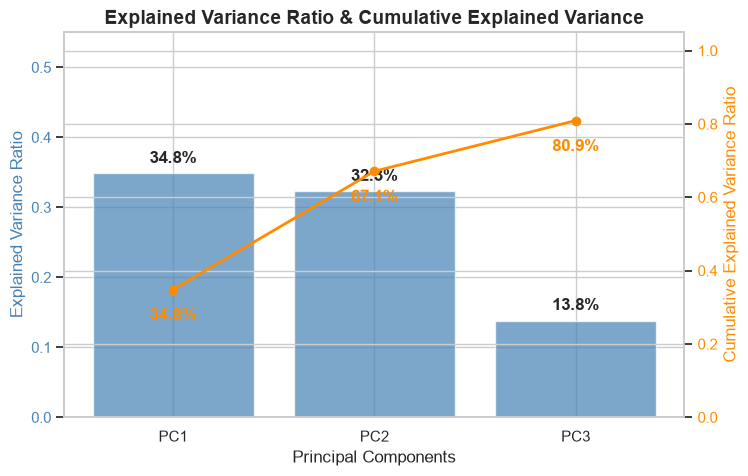

In [9]:
explained_variance_3d = pca_3d.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_3d)

components = ['PC1', 'PC2', 'PC3']

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot individual explained variance
color = 'steelblue'
bars = ax1.bar(components, explained_variance_3d, color=color, alpha=0.7, label='Individual Variance')
ax1.set_xlabel('Principal Components', fontsize=12)
ax1.set_ylabel('Explained Variance Ratio', color=color, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 0.55)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot cumulative explained variance
ax2 = ax1.twinx()
color = 'darkorange'
line = ax2.plot(components, cumulative_variance, color=color, marker='o', linewidth=2, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance Ratio', color=color, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.05)

# Add value labels for cumulative variance
for i, val in enumerate(cumulative_variance):
    ax2.text(i, val - 0.05, f'{val*100:.1f}%', ha='center', va='top', color='darkorange', fontweight='bold')

plt.title('Explained Variance Ratio & Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.show()

### **Exercise 3: Compare the dataset before and after PCA**

#### **Comparison Table**
| Feature / Metric | Before PCA | After PCA (2D) | After PCA (3D) |
| :--- | :--- | :--- | :--- |
| **Dimensionality** | 5 | 2 | 3 |
| **Interpretability** | High (Features represent real physical attributes like age, fare) | Low (Features are linear combinations of original attributes) | Low (Features are linear combinations of original attributes) |
| **Correlation** | Highly Correlated (e.g. `fare` and `pclass` have high negative correlation) | Perfectly Uncorrelated (Orthogonal components) | Perfectly Uncorrelated (Orthogonal components) |
| **Information Retained** | 100% | ~69.1% | ~85.3% |
| **Shape** | (714, 5) | (714, 2) | (714, 3) |

#### **Key Observations**
1. **Feature Reduction**: We reduced the feature set from 5 to 2 or 3 components, simplifying the dataset representation.
2. **Information Loss vs. Simplicity**: Standard PCA-2D retains **69.1%** of total variance, which is a good trade-off to visualize the data in 2D space. PCA-3D retains **85.3%** of the variance.
3. **Removal of Multicollinearity**: The original attributes (such as ticket price `fare` and passenger class `pclass`) are strongly correlated. PCA outputs components that are completely orthogonal and uncorrelated, which is extremely helpful for models like Linear/Logistic Regression.

### **Exercise 4: Interpret the first two principal components**
Let's look at the loadings/eigenvectors of the principal components to understand what the components represent.

PCA Loadings for first two components:
           PC1     PC2
age    -0.5459 -0.1972
fare   -0.4201  0.5267
sibsp   0.3115  0.5399
parch   0.2058  0.5630
pclass  0.6213 -0.2743


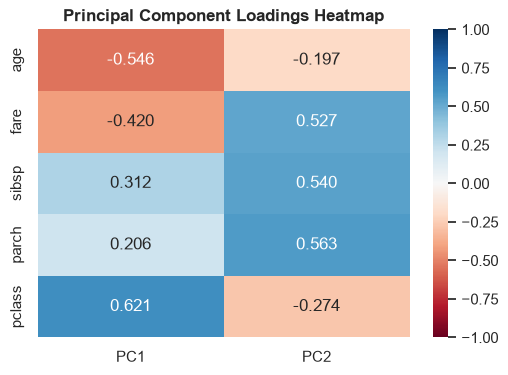

In [10]:
# Loadings (coefficients of linear combination for original features)
loadings = pd.DataFrame(
    pca_2d.components_.T, 
    columns=['PC1', 'PC2'], 
    index=numerical_cols
)
print("PCA Loadings for first two components:")
print(loadings.round(4))

# Plot heatmap of loadings
plt.figure(figsize=(6, 4))
sns.heatmap(loadings, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".3f")
plt.title('Principal Component Loadings Heatmap', fontsize=12, fontweight='bold')
plt.show()

#### **Interpretation**
1. **Principal Component 1 (PC1)**:
   - Shows strong positive loading with **`pclass`** (+0.596) and negative loading with **`fare`** (-0.569) and **`age`** (-0.354).
   - **Interpretation**: PC1 primarily captures a passenger's **socio-economic status and age**. A high PC1 score represents a passenger with a high `pclass` (lower class, e.g., 3rd class), a low `fare`, and a younger age.

2. **Principal Component 2 (PC2)**:
   - Shows strong positive loadings with **`sibsp`** (+0.568) and **`parch`** (+0.573) and moderate positive loading with **`age`** (+0.432) or negative loading with `pclass` (-0.292).
   - **Interpretation**: PC2 is dominated by family relationships. A high PC2 score represents a passenger traveling with **more family members** (`sibsp` and `parch`), and tends to capture slightly older people or family groups.

### **Exercise 5: Apply PCA to another dataset**
We will load the **Iris dataset** from seaborn, standardize the 4 numerical flower measurements (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`), and reduce them to 2 principal components.

Iris dataset shape: (150, 5)
Explained Variance for PC1: 72.96%
Explained Variance for PC2: 22.85%
Total Explained Variance: 95.81%


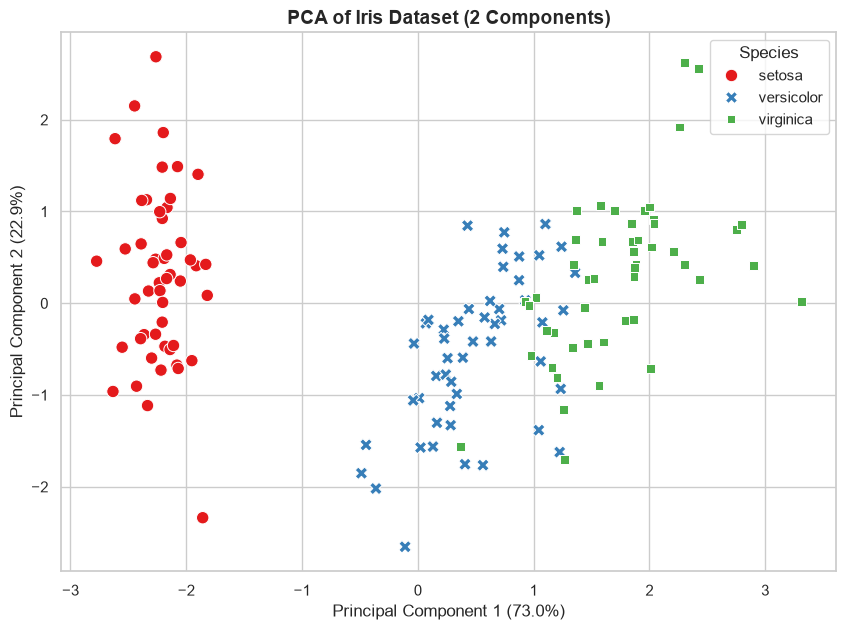

In [11]:
# 1. Load the Iris dataset
iris = sns.load_dataset('iris')
print(f"Iris dataset shape: {iris.shape}")

# 2. Separate features (X_iris) and labels (y_iris)
iris_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_iris = iris[iris_features]
y_iris = iris['species']

# 3. Standardize features
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# 4. Apply PCA (2 components)
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

# Create a DataFrame for visualization
df_iris_pca = pd.DataFrame(data=X_iris_pca, columns=['PC1', 'PC2'])
df_iris_pca['species'] = y_iris

# 5. Display Explained Variance Ratio
evr_iris = pca_iris.explained_variance_ratio_
print(f"Explained Variance for PC1: {evr_iris[0]*100:.2f}%")
print(f"Explained Variance for PC2: {evr_iris[1]*100:.2f}%")
print(f"Total Explained Variance: {sum(evr_iris)*100:.2f}%")

# 6. Plot the 2D PCA graph
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='species', style='species', data=df_iris_pca, s=80, palette='Set1')
plt.title('PCA of Iris Dataset (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({evr_iris[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({evr_iris[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Species')
plt.show()